# Unidad 2: Aprendizaje Automático
## ⚖️ Comparación de Modelos con K-Fold y Métricas
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

## 🎯 ¿Qué vamos a aprender?

En este notebook combinamos lo aprendido sobre **métricas de evaluación** y **K-Fold CV** para realizar una comparación sistemática de modelos con diferentes **conjuntos de features**.

Al finalizar, vas a poder:
- ✅ Diseñar una función reutilizable para evaluar modelos con K-Fold
- ✅ Comparar el rendimiento de modelos con **distintos subconjuntos de features**
- ✅ Evaluar con **múltiples métricas** simultáneamente (Accuracy, Precision, Recall, F1)
- ✅ Tomar decisiones de **selección de features** basadas en evidencia cuantitativa
- ✅ Interpretar los resultados en contexto (¿cuándo vale la pena más features?)

---

## 🧠 Marco Teórico

### 🏗️ Feature Engineering y Selección

Elegir qué variables usar para entrenar un modelo es una de las decisiones más importantes en ML:

| Más features | Menos features |
|-------------|----------------|
| Potencialmente mayor rendimiento | Modelo más simple e interpretable |
| Mayor riesgo de overfitting | Menor riesgo de overfitting |
| Mayor costo computacional | Menor costo computacional |
| Más difícil de mantener | Más fácil de mantener |

La selección óptima de features se hace de forma **empírica**: probamos diferentes subconjuntos y vemos cuál da mejor rendimiento validado con K-Fold.

### 🚢 Los tres subconjuntos que compararemos

| Modelo | Features | Interpretación |
|--------|----------|----------------|
| **M1** | Pclass, Sex, Age, Siblings/Spouses, Parents/Children, Fare | Todas las disponibles |
| **M2** | Pclass, Sex, Age | Solo factores sociodemográficos clave |
| **M3** | Fare, Age | Solo factores económicos y edad |

> 📌 **Referencias:**
> - Scikit-learn: [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)
> - Scikit-learn: [Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)
> - Guyon, I., & Elisseeff, A. (2003). [An Introduction to Variable and Feature Selection](https://www.jmlr.org/papers/v3/guyon03a.html). *JMLR*, 3, 1157–1182.

---

## 📦 Paso 1: Importar las Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 📂 Paso 2: Cargar el Dataset y Definir los Subconjuntos de Features

In [2]:
# 📥 Cargar dataset
df = pd.read_csv('https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/data/ml/titanic.csv')
df['male'] = df['Sex'] == 'male'

y = df['Survived'].values

# 🎯 Tres conjuntos distintos de features
X1 = df[['Pclass', 'male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
X2 = df[['Pclass', 'male', 'Age']].values
X3 = df[['Fare', 'Age']].values

print('📐 Dimensiones de los datasets:')
print(f'  X1 (todas las features):       {X1.shape}')
print(f'  X2 (Pclass, Sex, Age):         {X2.shape}')
print(f'  X3 (Fare, Age):                {X3.shape}')

print('\n🔢 Descripción:')
print('  X1: Incluye clase, sexo, edad, familia y tarifa')
print('  X2: Solo factores sociodemográficos principales')
print('  X3: Solo edad y tarifa (mínimo de información)')

📐 Dimensiones de los datasets:
  X1 (todas las features):       (887, 6)
  X2 (Pclass, Sex, Age):         (887, 3)
  X3 (Fare, Age):                (887, 2)

🔢 Descripción:
  X1: Incluye clase, sexo, edad, familia y tarifa
  X2: Solo factores sociodemográficos principales
  X3: Solo edad y tarifa (mínimo de información)


## 🛠️ Paso 3: Función de Evaluación con K-Fold

Definimos una función reutilizable que, dado un dataset X/y, ejecuta K-Fold y devuelve las 4 métricas promediadas.

In [3]:
def evaluar_con_kfold(X, y, kf):
    """Evalúa Logistic Regression con K-Fold y devuelve dict de métricas promedio."""
    acc_scores  = []
    prec_scores = []
    rec_scores  = []
    f1_scores   = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc_scores .append(accuracy_score(y_test, y_pred))
        prec_scores.append(precision_score(y_test, y_pred, zero_division=0))
        rec_scores .append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores  .append(f1_score(y_test, y_pred, zero_division=0))

    return {
        'Accuracy':  (np.mean(acc_scores),  np.std(acc_scores)),
        'Precision': (np.mean(prec_scores), np.std(prec_scores)),
        'Recall':    (np.mean(rec_scores),  np.std(rec_scores)),
        'F1 Score':  (np.mean(f1_scores),   np.std(f1_scores)),
    }

print('✅ Función de evaluación definida!')

✅ Función de evaluación definida!


## 🚀 Paso 4: Evaluar los Tres Modelos

In [4]:
# 🔄 Configurar K-Fold (mismo kf para los tres modelos = comparación justa)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('🚀 Evaluando los tres conjuntos de features con 5-Fold CV...')

resultados = {
    'M1: Todas las features':  evaluar_con_kfold(X1, y, kf),
    'M2: Pclass + Sex + Age':  evaluar_con_kfold(X2, y, kf),
    'M3: Fare + Age':          evaluar_con_kfold(X3, y, kf),
}

print('\n✅ Evaluación completada!')
print('\n' + '=' * 60)
print('       ⚖️  COMPARACIÓN DE MODELOS (5-Fold CV)')
print('=' * 60)

for nombre, metricas in resultados.items():
    print(f'\n  📋 {nombre}')
    for metrica, (media, std) in metricas.items():
        print(f'    {metrica:<12}: {media:.4f} ± {std:.4f}')

print('=' * 60)

🚀 Evaluando los tres conjuntos de features con 5-Fold CV...

✅ Evaluación completada!

       ⚖️  COMPARACIÓN DE MODELOS (5-Fold CV)

  📋 M1: Todas las features
    Accuracy    : 0.7949 ± 0.0360
    Precision   : 0.7544 ± 0.0248
    Recall      : 0.6944 ± 0.0837
    F1 Score    : 0.7213 ± 0.0557

  📋 M2: Pclass + Sex + Age
    Accuracy    : 0.7971 ± 0.0253
    Precision   : 0.7526 ± 0.0197
    Recall      : 0.7061 ± 0.0655
    F1 Score    : 0.7273 ± 0.0400

  📋 M3: Fare + Age
    Accuracy    : 0.6607 ± 0.0218
    Precision   : 0.6748 ± 0.0358
    Recall      : 0.2311 ± 0.0529
    F1 Score    : 0.3408 ± 0.0630


## 📊 Paso 5: Visualización Comparativa

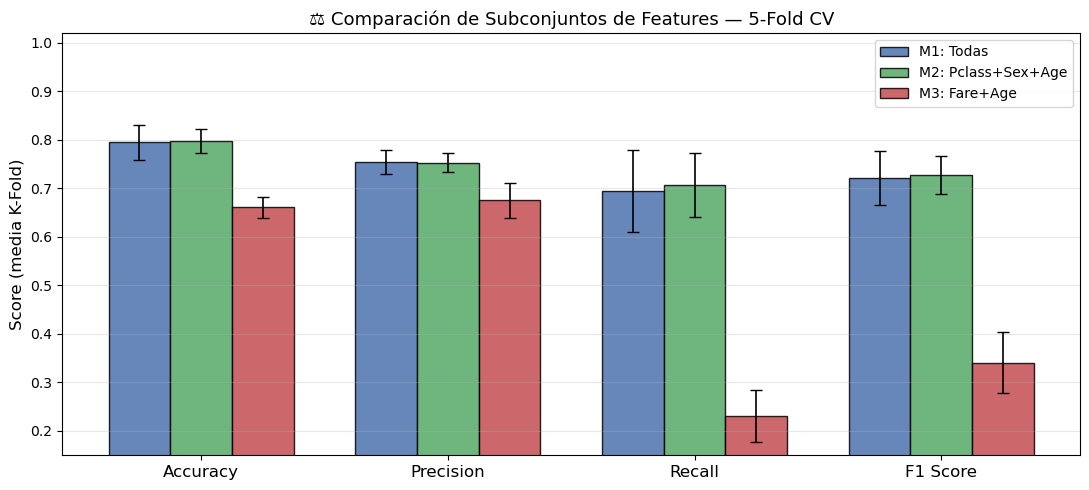

In [7]:
# 📊 Gráfico de barras agrupadas con barras de error
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
modelos_nombres  = ['M1: Todas', 'M2: Pclass+Sex+Age', 'M3: Fare+Age']
colores = ['#4C72B0', '#55A868', '#C44E52']

medias = [[resultados[n][m][0] for m in metricas_nombres] for n in resultados]
stds   = [[resultados[n][m][1] for m in metricas_nombres] for n in resultados]

x = np.arange(len(metricas_nombres))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (mod, med, std, col) in enumerate(zip(modelos_nombres, medias, stds, colores)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, med, width,
                  label=mod, color=col, edgecolor='black', alpha=0.85)
    ax.errorbar(x + offset, med, yerr=std, fmt='none',
                color='black', capsize=4, linewidth=1.2)

ax.set_ylabel('Score (media K-Fold)', fontsize=12)
ax.set_title('⚖️ Comparación de Subconjuntos de Features — 5-Fold CV', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres, fontsize=12)
ax.set_ylim(0.15, 1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🎯 Paso 6: Tabla Resumen y Análisis

In [6]:
# 📋 Tabla resumen
filas = []
for nombre, metricas in resultados.items():
    fila = {'Modelo': nombre.split(':')[0]}
    for met, (mean, std) in metricas.items():
        fila[met] = f'{mean:.4f} ± {std:.4f}'
    filas.append(fila)

tabla = pd.DataFrame(filas).set_index('Modelo')
print('📋 Tabla resumen completa:')
print(tabla.to_string())

# Análisis automático
print('\n' + '─' * 55)
print('🔍 Análisis:')
for met in metricas_nombres:
    vals = [(nombre, resultados[nombre][met][0]) for nombre in resultados]
    mejor = max(vals, key=lambda x: x[1])
    print(f'  Mejor {met:<12}: {mejor[0].split(":")[0]} ({mejor[1]:.4f})')

📋 Tabla resumen completa:
               Accuracy        Precision           Recall         F1 Score
Modelo                                                                    
M1      0.7949 ± 0.0360  0.7544 ± 0.0248  0.6944 ± 0.0837  0.7213 ± 0.0557
M2      0.7971 ± 0.0253  0.7526 ± 0.0197  0.7061 ± 0.0655  0.7273 ± 0.0400
M3      0.6607 ± 0.0218  0.6748 ± 0.0358  0.2311 ± 0.0529  0.3408 ± 0.0630

───────────────────────────────────────────────────────
🔍 Análisis:
  Mejor Accuracy    : M2 (0.7971)
  Mejor Precision   : M1 (0.7544)
  Mejor Recall      : M2 (0.7061)
  Mejor F1 Score    : M2 (0.7273)


## 🏁 Conclusiones

En este notebook aprendimos:

1. 🛠️ Diseñar una **función de evaluación reutilizable** que aplica K-Fold y calcula múltiples métricas simultáneamente.
2. ⚖️ Usar el **mismo objeto KFold** para los distintos modelos garantiza una **comparación justa** (mismos folds).
3. 📊 Reportar **media ± desviación estándar** da más información que un único score.
4. 🎯 No siempre más features = mejor modelo: M2 (solo 3 variables) suele acercarse mucho a M1 (6 variables), siendo más simple e interpretable.
5. 🔍 M3 (Fare + Age) muestra los límites: con muy poca información, el rendimiento cae notablemente.

### ➡️ Próximo notebook: Comparación de modelos con Curvas ROC y AUC

---

## 📚 Referencias

- Guyon, I., & Elisseeff, A. (2003). [An Introduction to Variable and Feature Selection](https://www.jmlr.org/papers/v3/guyon03a.html). *JMLR*, 3, 1157–1182.
- Scikit-learn: [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)
- Scikit-learn: [Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)
- Géron, A. (2019). *Hands-On Machine Learning*, Cap. 2 y 3. O'Reilly.